# 03 — ResNet-50 Grad-CAM and ROI Mask Qualitative Analysis

This notebook adds interpretability to the ResNet-50 mass-classification baseline from notebook 02.

It loads the saved ResNet-50 checkpoint, evaluates the locked CBIS-DDSM mass test set, and generates Grad-CAM visualisations for four clinically useful cases:

- true malignant correctly classified;
- false negative;
- false positive;
- true benign/not-malignant correctly classified.

The Grad-CAM maps are compared qualitatively with the CBIS-DDSM ROI mask images. This is an interpretability analysis only: ROI masks are **not** used for model training in this baseline.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Configuration

The paths match notebook 02. This notebook expects the ResNet-50 checkpoint and cached arrays created by the baseline notebook.

In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_dissertation"
DATA_DIR    = os.path.join(PROJECT_DIR, "Data", "CBIS-DDSM")
JPEG_DIR    = os.path.join(DATA_DIR, "jpeg")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache")
MODEL_DIR   = os.path.join(PROJECT_DIR, "Models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")

MODEL_PATH = os.path.join(MODEL_DIR, "resnet50_mass_baseline_patient_split.pth")
FIG_PATH   = os.path.join(RESULTS_DIR, "resnet50_gradcam_roi_examples.png")

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

## 2. Imports and Device Setup

Grad-CAM requires gradients, so the model is placed in evaluation mode but gradients are still enabled for the selected target class during CAM generation.

In [3]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "| GPU:", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

Device: cpu | GPU: CPU


## 3. Rebuild Test Metadata With ROI Links

The same image-level construction used in notebook 02 is repeated here so that predictions can be linked back to the original mammogram and ROI mask folders.

The grouping remains one row per physical mammogram. If multiple abnormalities are linked to the same mammogram, the image label is malignant if any linked abnormality is malignant. ROI mask paths from all linked abnormalities are retained for qualitative inspection.

In [4]:
def uid_from(path):
    return str(path).split("/")[-2]


def jpegs_from_metadata_path(metadata_path):
    folder = os.path.join(JPEG_DIR, uid_from(metadata_path))
    if not os.path.isdir(folder):
        return []
    return [
        os.path.join(folder, fname)
        for fname in sorted(os.listdir(folder))
        if fname.lower().endswith((".jpg", ".jpeg", ".png"))
    ]


def first_jpeg_from_metadata_path(metadata_path):
    files = jpegs_from_metadata_path(metadata_path)
    return files[0] if files else None


def join_unique_paths(paths):
    out = []
    for p in paths:
        if isinstance(p, str) and p not in out:
            out.append(p)
    return "||".join(out)


def build_img_df_with_roi(case_csv):
    df = pd.read_csv(os.path.join(DATA_DIR, case_csv))
    df["label"] = (df["pathology"].str.upper() == "MALIGNANT").astype(int)
    df["full_jpeg"] = df["image file path"].apply(first_jpeg_from_metadata_path)

    out = (
        df.dropna(subset=["full_jpeg"])
          .groupby(["patient_id", "left or right breast", "image view"], as_index=False)
          .agg(
              full_jpeg=("full_jpeg", "first"),
              label=("label", "max"),
              pathology=("pathology", lambda x: "; ".join(sorted(set(map(str, x))))),
              assessment=("assessment", lambda x: "; ".join(sorted(set(map(str, x))))),
              breast_density=("breast_density", "first"),
              mass_shape=("mass shape", lambda x: "; ".join(sorted(set(map(str, x))))),
              mass_margins=("mass margins", lambda x: "; ".join(sorted(set(map(str, x))))),
              roi_mask_paths=("ROI mask file path", join_unique_paths),
              cropped_paths=("cropped image file path", join_unique_paths),
          )
    )
    return out


img_df_test = build_img_df_with_roi("mass_case_description_test_set.csv")
print("Locked test images:", len(img_df_test))
display(img_df_test.head())

Locked test images: 361


,patient_id,left or right breast,image view,full_jpeg,label,pathology,assessment,breast_density,mass_shape,mass_margins,roi_mask_paths,cropped_paths
0,P_00016,LEFT,CC,/content/drive/MyDrive/BreastCancer_dissertati...,1,MALIGNANT,5,4,IRREGULAR,SPICULATED,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,LEFT,MLO,/content/drive/MyDrive/BreastCancer_dissertati...,1,MALIGNANT,5,4,IRREGULAR,SPICULATED,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,LEFT,CC,/content/drive/MyDrive/BreastCancer_dissertati...,1,MALIGNANT,4,2,ROUND,CIRCUMSCRIBED,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,LEFT,MLO,/content/drive/MyDrive/BreastCancer_dissertati...,1,MALIGNANT,4,2,ROUND,ILL_DEFINED,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,RIGHT,CC,/content/drive/MyDrive/BreastCancer_dissertati...,0,BENIGN,0,3,ROUND,OBSCURED,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....


## 4. Load Validated Test Cache

The cached test array from notebook 02 is reused. The row identifiers and labels are checked again to ensure the metadata rows are aligned with the cached images.

In [5]:
def row_keys(df):
    return (
        df["patient_id"].astype(str) + "|" +
        df["left or right breast"].astype(str) + "|" +
        df["image view"].astype(str)
    ).to_numpy()


def preprocess(df, size=IMG_SIZE):
    X = np.zeros((len(df), size, size), dtype=np.uint8)
    y = df["label"].to_numpy(dtype=np.int64)
    for i, path in enumerate(tqdm(df["full_jpeg"].tolist(), desc="preprocessing test images")):
        X[i] = np.array(Image.open(path).convert("L").resize((size, size)), dtype=np.uint8)
    return X, y


def load_or_build_test_cache(df):
    cache = os.path.join(CACHE_DIR, "mass_test_224.npz")
    expected_keys = row_keys(df)
    expected_y = df["label"].to_numpy(dtype=np.int64)

    if os.path.exists(cache):
        d = np.load(cache, allow_pickle=True)
        if "row_key" in d.files and np.array_equal(d["row_key"].astype(str), expected_keys.astype(str)) and np.array_equal(d["y"], expected_y):
            print("Loaded validated cache: mass_test_224.npz")
            return d["X"], d["y"]
        print("Cache mismatch detected; rebuilding test cache")

    X, y = preprocess(df)
    np.savez_compressed(cache, X=X, y=y, row_key=expected_keys)
    return X, y


X_test, y_test = load_or_build_test_cache(img_df_test)
print("Test array:", X_test.shape)

Loaded validated cache: mass_test_224.npz
Test array: (361, 224, 224)


## 5. Load ResNet-50 Baseline Checkpoint

The architecture must match notebook 02 exactly: ImageNet-pretrained ResNet-50 with a two-class final layer.

In [6]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class ArrayDS(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        t = torch.from_numpy(np.stack([self.X[i]] * 3, axis=0)).float() / 255.0
        return (t - MEAN) / STD, int(self.y[i])


test_loader = DataLoader(
    ArrayDS(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Loaded model:", MODEL_PATH)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


Loaded model: /content/drive/MyDrive/BreastCancer_dissertation/Models/resnet50_mass_baseline_patient_split.pth


## 6. Generate Locked Test Predictions

The four qualitative examples are selected from the locked test set after computing model probabilities.

In [7]:
@torch.no_grad()
def eval_probs(loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        p = torch.softmax(model(x.to(device)), dim=1)[:, 1].cpu().numpy()
        ps.extend(p.tolist())
        ys.extend(y.tolist())
    return np.array(ys), np.array(ps)


yt, pt = eval_probs(test_loader)
pred = (pt >= 0.5).astype(int)

print("Locked test AUC:", round(roc_auc_score(yt, pt), 4))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(yt, pred))

pred_df = img_df_test.copy()
pred_df["y_true"] = yt
pred_df["p_malignant"] = pt
pred_df["y_pred"] = pred
pred_df["outcome"] = np.select(
    [
        (pred_df["y_true"] == 1) & (pred_df["y_pred"] == 1),
        (pred_df["y_true"] == 1) & (pred_df["y_pred"] == 0),
        (pred_df["y_true"] == 0) & (pred_df["y_pred"] == 1),
        (pred_df["y_true"] == 0) & (pred_df["y_pred"] == 0),
    ],
    ["true_malignant", "false_negative", "false_positive", "true_not_malignant"],
    default="other",
)

display(pred_df[["patient_id", "left or right breast", "image view", "y_true", "p_malignant", "y_pred", "outcome"]].head())

Locked test AUC: 0.7965
Confusion matrix [[TN, FP], [FN, TP]]:
[[146  70]
 [ 35 110]]


,patient_id,left or right breast,image view,y_true,p_malignant,y_pred,outcome
0,P_00016,LEFT,CC,1,0.209746,0,false_negative
1,P_00016,LEFT,MLO,1,0.309009,0,false_negative
2,P_00017,LEFT,CC,1,0.822459,1,true_malignant
3,P_00017,LEFT,MLO,1,0.945577,1,true_malignant
4,P_00032,RIGHT,CC,0,0.089766,0,true_not_malignant


## 7. Select Representative Cases

Representative examples are selected deterministically:

- true malignant: highest malignant probability among true positives;
- false negative: lowest malignant probability among missed malignant cases;
- false positive: highest malignant probability among non-malignant cases predicted malignant;
- true not-malignant: lowest malignant probability among true negatives.

This gives visually clear examples of model behaviour. The final write-up should state that these are qualitative examples rather than a quantitative localisation evaluation.

In [8]:
def pick_case(df, outcome, ascending):
    sub = df[df["outcome"] == outcome].copy()
    if len(sub) == 0:
        return None
    return sub.sort_values("p_malignant", ascending=ascending).index[0]


case_indices = {
    "True malignant correctly classified": pick_case(pred_df, "true_malignant", ascending=False),
    "False negative": pick_case(pred_df, "false_negative", ascending=True),
    "False positive": pick_case(pred_df, "false_positive", ascending=False),
    "True not-malignant correctly classified": pick_case(pred_df, "true_not_malignant", ascending=True),
}

case_indices = {k: v for k, v in case_indices.items() if v is not None}

for label, idx in case_indices.items():
    r = pred_df.loc[idx]
    print(f"{label}: index={idx}, patient={r['patient_id']}, true={r['y_true']}, pred={r['y_pred']}, p_malignant={r['p_malignant']:.3f}")

True malignant correctly classified: index=126, patient=P_00576, true=1, pred=1, p_malignant=1.000
False negative: index=163, patient=P_00758, true=1, pred=0, p_malignant=0.004
False positive: index=132, patient=P_00601, true=0, pred=1, p_malignant=1.000
True not-malignant correctly classified: index=95, patient=P_00433, true=0, pred=0, p_malignant=0.000


## 8. Grad-CAM Helper Functions

The Grad-CAM target is fixed to the **malignant class** for all examples. This answers a clinically meaningful question: where does the model find image evidence for malignancy?

In [11]:
def tensor_from_array(arr):
    t = torch.from_numpy(np.stack([arr] * 3, axis=0)).float() / 255.0
    return ((t - MEAN) / STD).unsqueeze(0).to(device)


def compute_gradcam(model, arr, target_class=1):
    activations = []
    gradients = []

    target_layer = model.layer4[-1]

    def forward_hook(module, inputs, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad(set_to_none=True)
    x = tensor_from_array(arr)
    logits = model(x)
    score = logits[:, target_class].sum()
    score.backward()

    act = activations[0]
    grad = gradients[0]
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam_map = (weights * act).sum(dim=1, keepdim=True)
    cam_map = F.relu(cam_map)
    cam_map = F.interpolate(cam_map, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    cam_map = cam_map.squeeze().detach().cpu().numpy()

    cam_map = cam_map - cam_map.min()
    if cam_map.max() > 0:
        cam_map = cam_map / cam_map.max()

    h1.remove()
    h2.remove()
    return cam_map


def overlay_cam(gray, cam_map, alpha=0.45):
    gray_norm = gray.astype(float) / 255.0
    rgb = np.dstack([gray_norm, gray_norm, gray_norm])
    heat = matplotlib.colormaps["jet"](cam_map)[:, :, :3]
    return np.clip((1 - alpha) * rgb + alpha * heat, 0, 1)


def binary_likeness(path):
    arr = np.array(Image.open(path).convert("L"))
    if arr.size == 0:
        return -1
    near_binary = np.mean((arr < 20) | (arr > 235))
    contrast = arr.std() / 255.0
    return near_binary + contrast


def best_roi_mask_path(row):
    paths = []
    for metadata_path in str(row["roi_mask_paths"]).split("||"):
        paths.extend(jpegs_from_metadata_path(metadata_path))
    paths = list(dict.fromkeys(paths))
    if not paths:
        return None
    return sorted(paths, key=binary_likeness, reverse=True)[0]


def load_roi_mask_for_display(row):
    path = best_roi_mask_path(row)
    if path is None:
        return None, None
    arr = np.array(Image.open(path).convert("L"))
    return arr, path

## 9. Visualise Grad-CAM Against ROI Masks

Each row shows the full mammogram, malignant-class Grad-CAM overlay, and the corresponding ROI mask image provided by CBIS-DDSM.

The ROI mask is shown as the dataset provides it. Depending on the converted image folder, the mask may be in cropped-lesion coordinates rather than directly registered to the resized full mammogram; therefore, this notebook uses the masks for qualitative comparison, not quantitative localisation scoring.

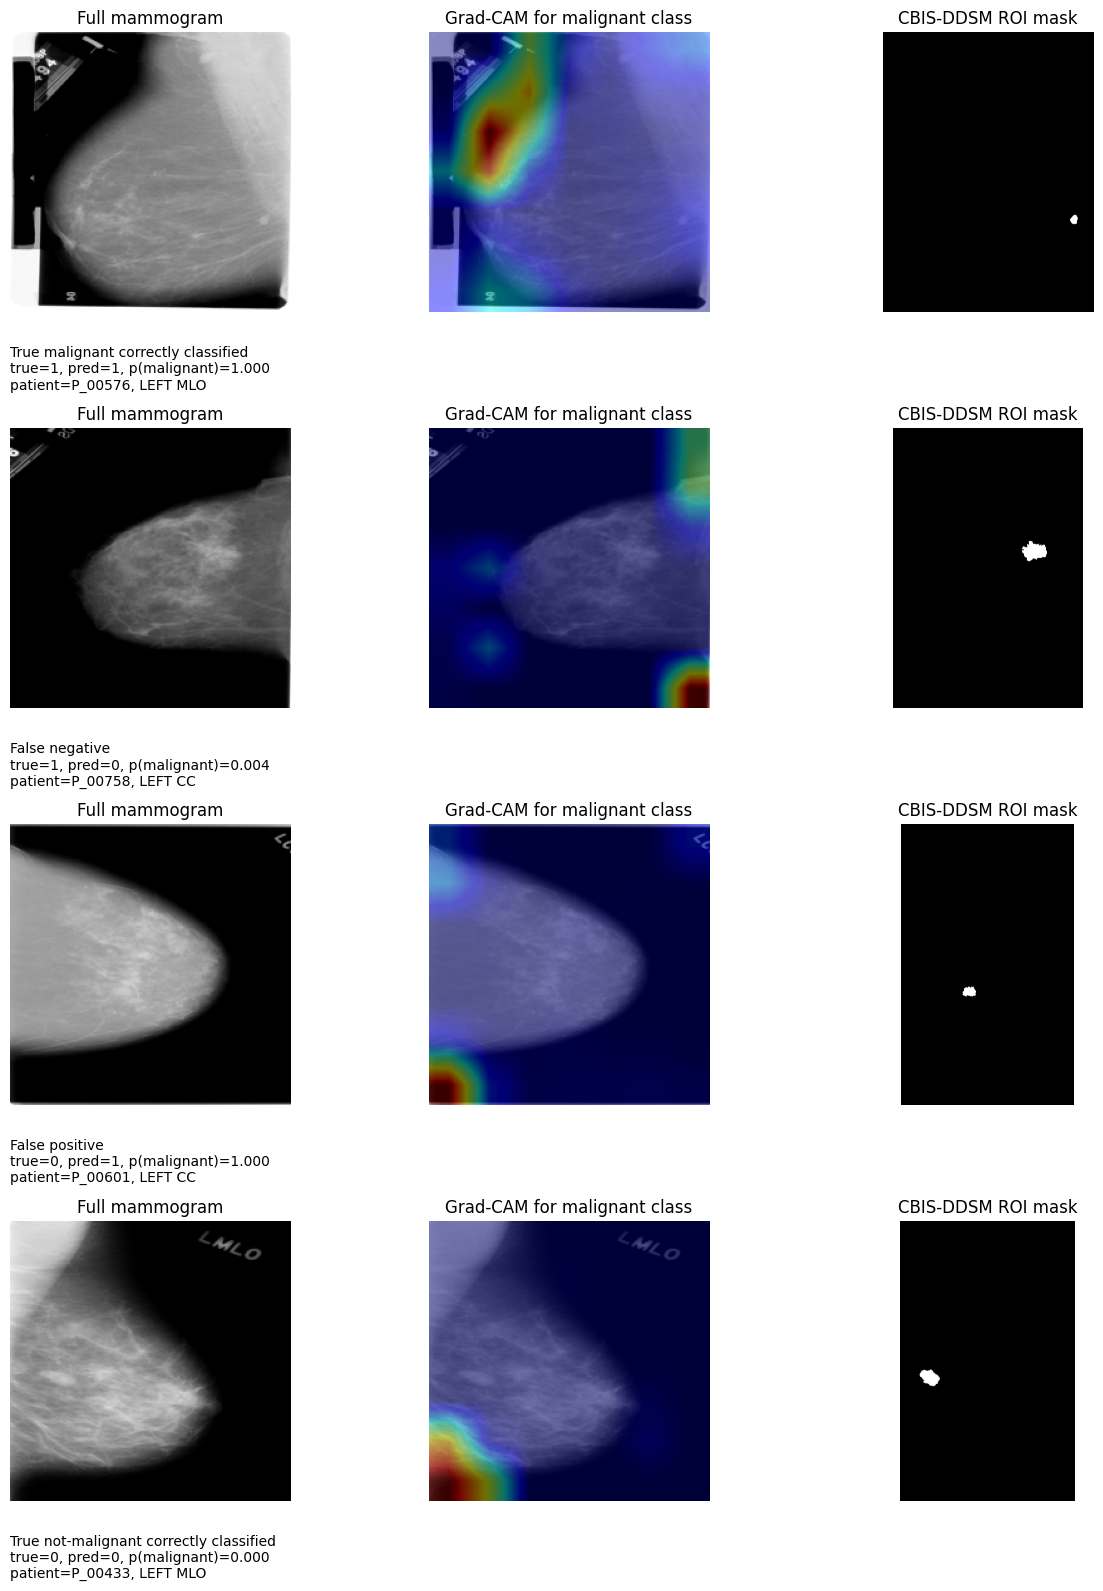

Saved Grad-CAM figure to: /content/drive/MyDrive/BreastCancer_dissertation/Results/resnet50_gradcam_roi_examples.png


In [10]:
n_cases = len(case_indices)
fig, axes = plt.subplots(n_cases, 3, figsize=(13, 4 * n_cases))
if n_cases == 1:
    axes = np.array([axes])

for row_i, (case_label, idx) in enumerate(case_indices.items()):
    row = pred_df.loc[idx]
    gray = X_test[idx]
    cam_map = compute_gradcam(model, gray, target_class=1)
    overlay = overlay_cam(gray, cam_map)
    roi_arr, roi_path = load_roi_mask_for_display(row)

    title = (
        f"{case_label}\n"
        f"true={int(row['y_true'])}, pred={int(row['y_pred'])}, p(malignant)={row['p_malignant']:.3f}\n"
        f"patient={row['patient_id']}, {row['left or right breast']} {row['image view']}"
    )

    axes[row_i, 0].imshow(gray, cmap="gray")
    axes[row_i, 0].set_title("Full mammogram")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(overlay)
    axes[row_i, 1].set_title("Grad-CAM for malignant class")
    axes[row_i, 1].axis("off")

    if roi_arr is not None:
        axes[row_i, 2].imshow(roi_arr, cmap="gray")
        axes[row_i, 2].set_title("CBIS-DDSM ROI mask")
    else:
        axes[row_i, 2].text(0.5, 0.5, "ROI mask not found", ha="center", va="center")
        axes[row_i, 2].set_title("CBIS-DDSM ROI mask")
    axes[row_i, 2].axis("off")

    axes[row_i, 0].text(
        0.0, -0.12, title,
        transform=axes[row_i, 0].transAxes,
        fontsize=10,
        va="top",
    )

plt.tight_layout()
plt.savefig(FIG_PATH, dpi=200, bbox_inches="tight")
plt.show()
print("Saved Grad-CAM figure to:", FIG_PATH)

## 10. ROI Alignment Verification

This section checks whether the CBIS-DDSM ROI mask can be interpreted in the same spatial coordinate system as the full mammogram.

For each selected case, the notebook displays:

- full mammogram;
- malignant-class Grad-CAM overlay;
- cropped lesion image from the CBIS-DDSM crop folder;
- ROI mask from the CBIS-DDSM ROI folder.

This is a practical visual check before any future quantitative localisation metric. If the ROI mask visually belongs to the cropped lesion rather than the full mammogram, it should not be used for direct full-image Grad-CAM IoU or Dice without a dedicated registration step.

In [12]:
def first_existing_jpeg_from_joined_paths(joined_paths):
    for metadata_path in str(joined_paths).split("||"):
        files = jpegs_from_metadata_path(metadata_path)
        if files:
            return files[0]
    return None


def load_cropped_lesion_for_display(row):
    path = first_existing_jpeg_from_joined_paths(row["cropped_paths"])
    if path is None:
        return None, None
    return np.array(Image.open(path).convert("L")), path


def select_alignment_cases(pred_df, max_cases=8):
    selected = []

    # Keep the four outcome examples already used for Grad-CAM interpretation.
    for idx in case_indices.values():
        if idx not in selected:
            selected.append(idx)

    # Add extra malignant and non-malignant examples for a broader visual check.
    candidates = (
        pred_df.assign(confidence=np.abs(pred_df["p_malignant"] - 0.5))
               .sort_values("confidence", ascending=False)
               .index
               .tolist()
    )
    for idx in candidates:
        if idx not in selected:
            selected.append(idx)
        if len(selected) >= max_cases:
            break

    return selected[:max_cases]


alignment_indices = select_alignment_cases(pred_df, max_cases=8)
print("Selected cases for ROI alignment check:", alignment_indices)

Selected cases for ROI alignment check: [np.int64(126), np.int64(163), np.int64(132), np.int64(95), 93, 121, 92, 28]


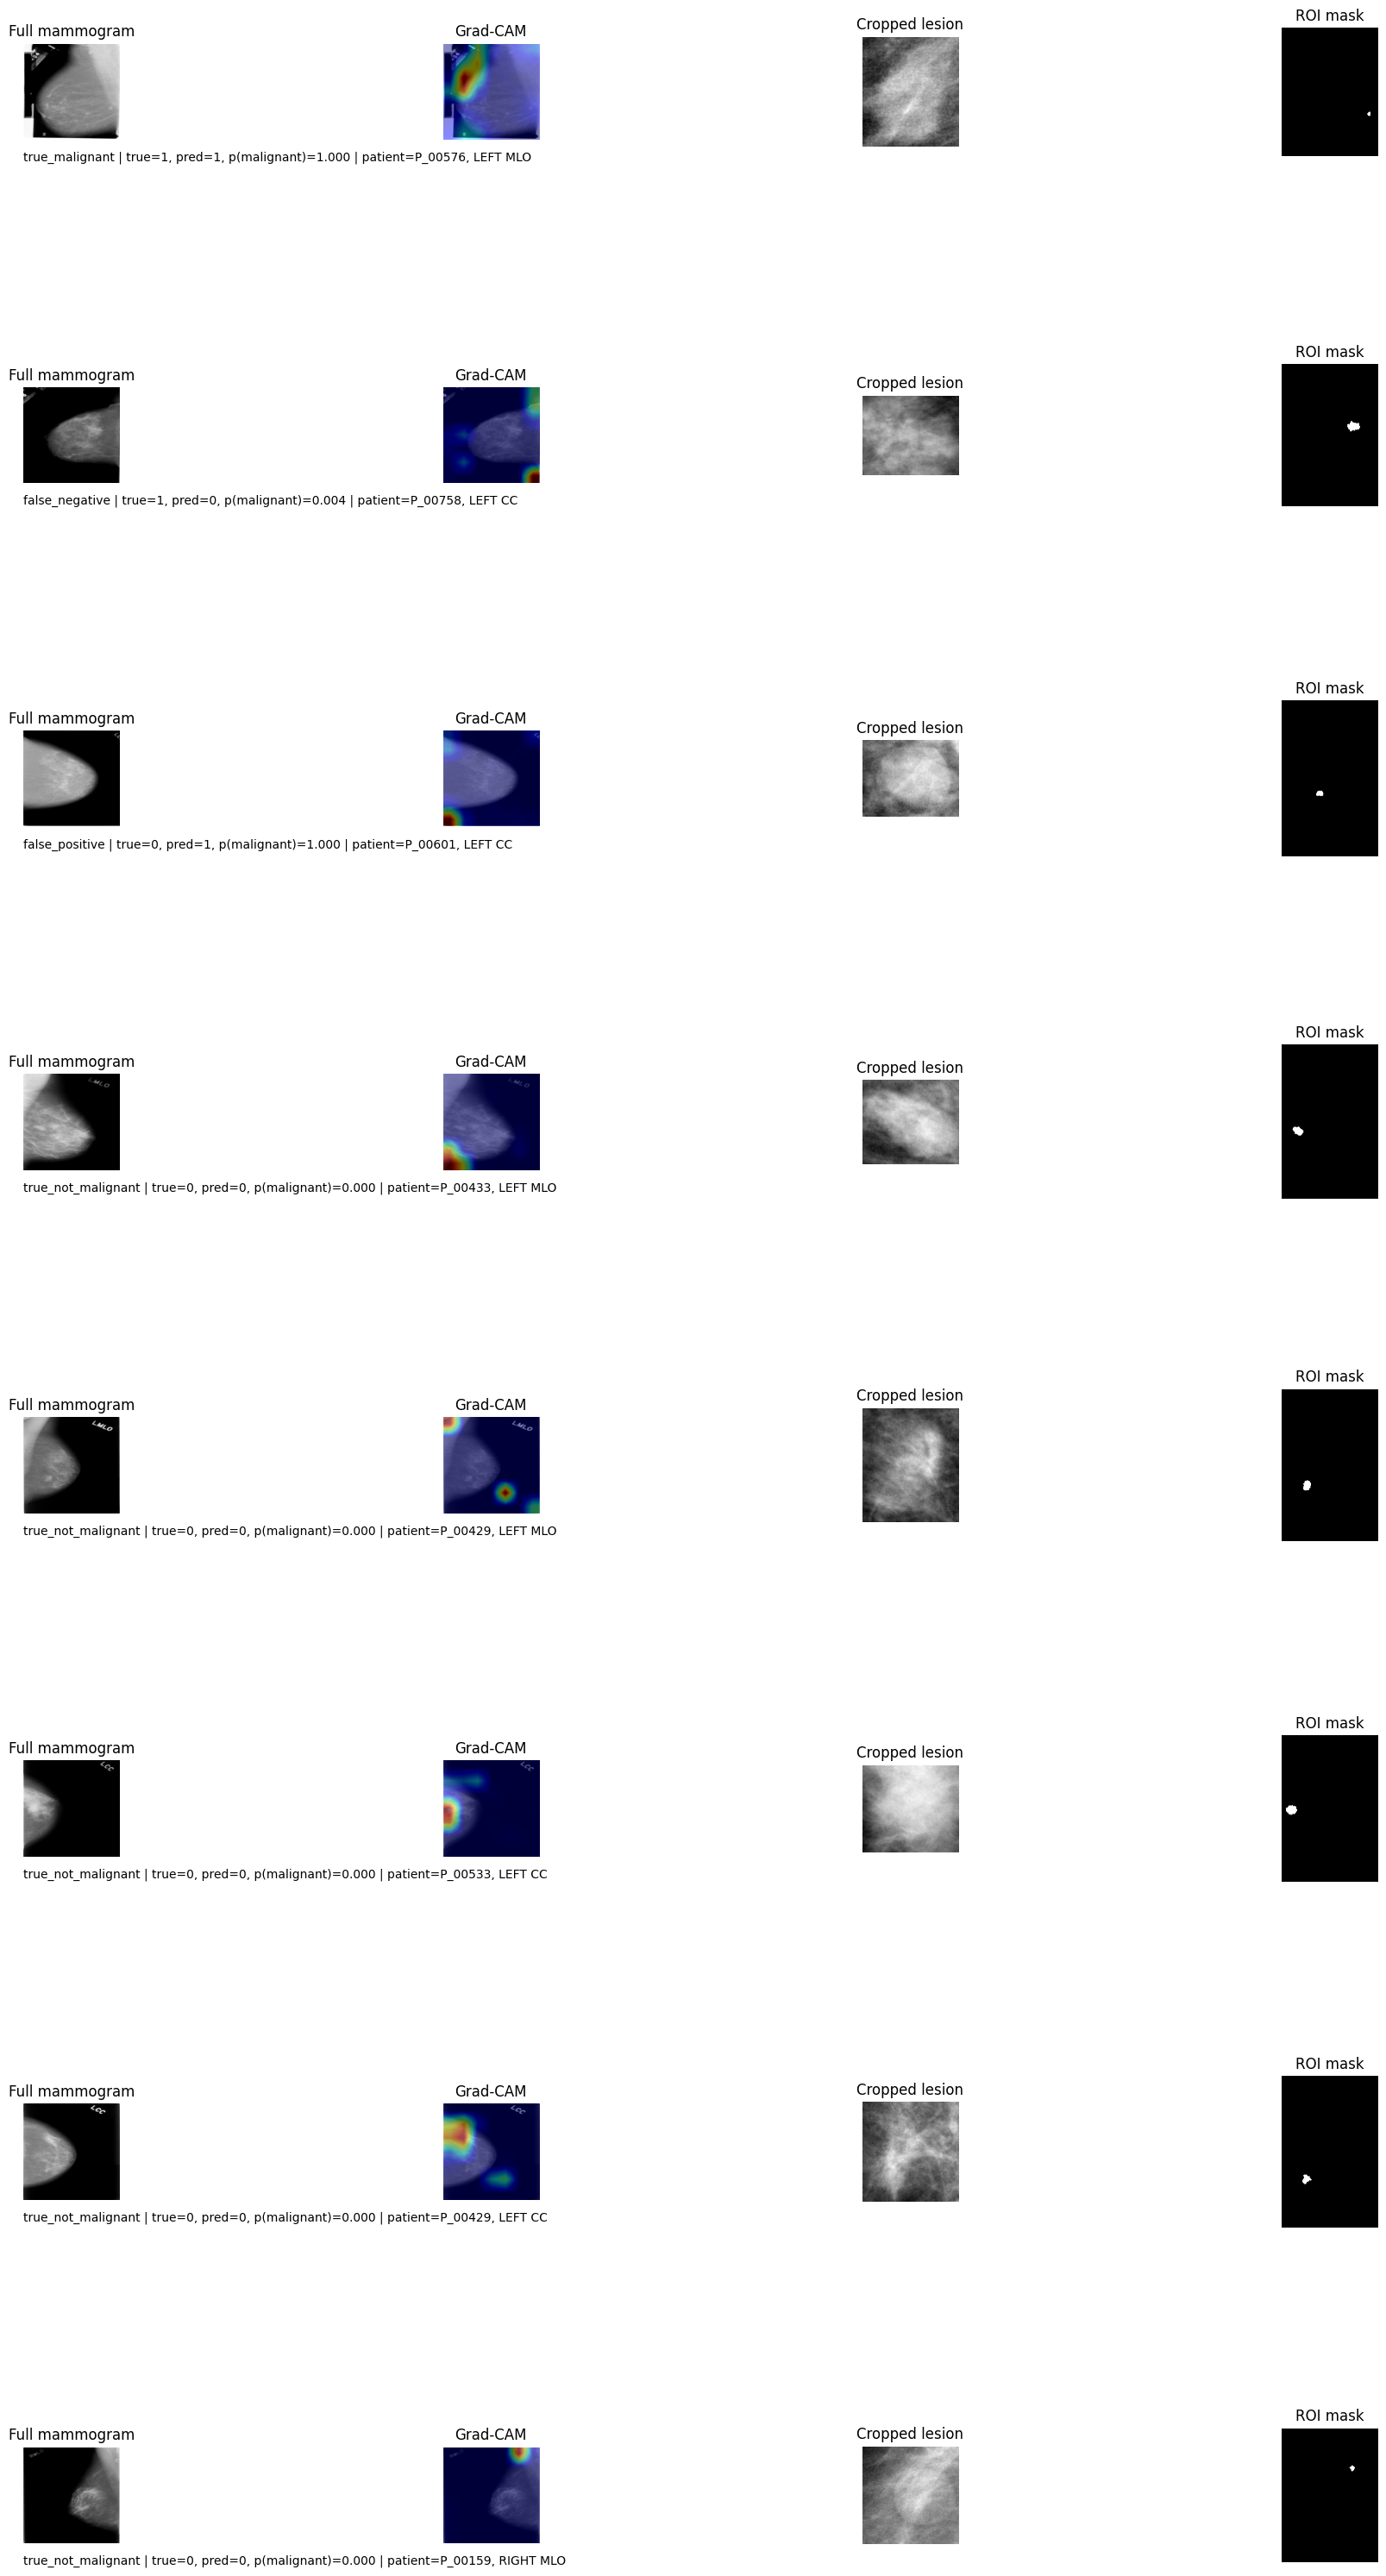

In [13]:
n_align = len(alignment_indices)
fig, axes = plt.subplots(n_align, 4, figsize=(16, 4 * n_align))
if n_align == 1:
    axes = np.array([axes])

for row_i, idx in enumerate(alignment_indices):
    row = pred_df.loc[idx]
    gray = X_test[idx]
    cam_map = compute_gradcam(model, gray, target_class=1)
    overlay = overlay_cam(gray, cam_map)
    crop_arr, crop_path = load_cropped_lesion_for_display(row)
    roi_arr, roi_path = load_roi_mask_for_display(row)

    axes[row_i, 0].imshow(gray, cmap="gray")
    axes[row_i, 0].set_title("Full mammogram")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(overlay)
    axes[row_i, 1].set_title("Grad-CAM")
    axes[row_i, 1].axis("off")

    if crop_arr is not None:
        axes[row_i, 2].imshow(crop_arr, cmap="gray")
        axes[row_i, 2].set_title("Cropped lesion")
    else:
        axes[row_i, 2].text(0.5, 0.5, "Crop not found", ha="center", va="center")
        axes[row_i, 2].set_title("Cropped lesion")
    axes[row_i, 2].axis("off")

    if roi_arr is not None:
        axes[row_i, 3].imshow(roi_arr, cmap="gray")
        axes[row_i, 3].set_title("ROI mask")
    else:
        axes[row_i, 3].text(0.5, 0.5, "ROI not found", ha="center", va="center")
        axes[row_i, 3].set_title("ROI mask")
    axes[row_i, 3].axis("off")

    caption = (
        f"{row['outcome']} | true={int(row['y_true'])}, pred={int(row['y_pred'])}, "
        f"p(malignant)={row['p_malignant']:.3f} | patient={row['patient_id']}, "
        f"{row['left or right breast']} {row['image view']}"
    )
    axes[row_i, 0].text(0.0, -0.12, caption, transform=axes[row_i, 0].transAxes, fontsize=10, va="top")

plt.tight_layout()
plt.show()

### ROI Alignment Observation

The ROI masks correspond to cropped lesion annotations provided by CBIS-DDSM rather than full-mammogram coordinates. Therefore, they are presented as qualitative reference images rather than used for direct pixel-wise overlap with the Grad-CAM heatmaps.
If future work requires quantitative localisation, a separate registration step is required before computing IoU, Dice, or pointing-game metrics.

## 11. Interpretation Guide

Use this section when writing the dissertation discussion.

For true positives, a reassuring pattern is Grad-CAM activation near the ROI mask or lesion-bearing region. For false negatives, weak or misplaced malignant-class activation can suggest that the model failed to focus on the lesion. For false positives, activation outside the ROI or on dense parenchymal tissue may indicate spurious cues. For true not-malignant cases, low malignant evidence or diffuse activation is expected.

This analysis is qualitative and should not be overclaimed. A stronger future extension would compute quantitative localisation agreement between Grad-CAM maps and ROI masks, but that requires careful spatial registration of ROI masks to the full mammogram coordinate system.